<a href="https://colab.research.google.com/github/HolwJeage/proyecto-ds-servidores-/blob/main/proyecto_ciencia_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Configuración de estilo
sns.set_theme(style="whitegrid")
np.random.seed(42)

# 1. GENERACIÓN DEL DATASET CRUDO
n_samples = 500
data = {
    "server_id": [f"SRV-{i:03d}" for i in range(1, n_samples + 1)],
    "cpu_usage_pct": np.random.uniform(10, 100, n_samples),
    "ram_usage_pct": np.random.uniform(20, 98, n_samples),
    "disk_io_mbps": np.random.uniform(5, 500, n_samples),
    "latency_ms": np.random.uniform(1, 150, n_samples),
    "os_type": np.random.choice(
        ["Linux", "Windows", "Ubuntu", None], n_samples, p=[0.5, 0.3, 0.15, 0.05]
    ),
    "server_status": np.random.choice(
        ["Healthy", "Warning", "Critical"], n_samples, p=[0.7, 0.2, 0.1]
    ),
}

df = pd.DataFrame(data)

# Introducir nulos y duplicados intencionales para practicar la limpieza
df.loc[10:15, "cpu_usage_pct"] = np.nan
df = pd.concat([df, df.iloc[[0, 1]]], ignore_index=True)

print("Dataset crudo cargado con éxito.")

Dataset crudo cargado con éxito.


In [7]:
# Inspección inicial
print(f"Filas duplicadas detectadas: {df.duplicated().sum()}")
print("Valores nulos por columna:\n", df.isnull().sum())

# Limpieza
df_clean = df.drop_duplicates().copy()

# Imputación de nulos
cpu_median = df_clean["cpu_usage_pct"].median()
df_clean["cpu_usage_pct"].fillna(cpu_median, inplace=True)

os_mode = df_clean["os_type"].mode()[0]
df_clean["os_type"].fillna(os_mode, inplace=True)

print(
    "\n=== DATASET LIMPIO ===\nDimensión final:",
    df_clean.shape,
    "\nNulos restantes:",
    df_clean.isnull().sum().sum(),
)

Filas duplicadas detectadas: 2
Valores nulos por columna:
 server_id         0
cpu_usage_pct     6
ram_usage_pct     0
disk_io_mbps      0
latency_ms        0
os_type          26
server_status     0
dtype: int64

=== DATASET LIMPIO ===
Dimensión final: (500, 7) 
Nulos restantes: 0


=== RESUMEN ESTADÍSTICO ===
         cpu_usage_pct  ram_usage_pct  disk_io_mbps  latency_ms
count           500.00         500.00        500.00      500.00
mean             54.99          57.59        261.19       74.97
std              26.63          22.27        147.11       42.76
min              10.46          20.36          7.45        1.48
25%              32.40          37.87        124.41       36.92
50%              56.37          56.80        272.17       76.82
75%              77.83          76.65        389.79      110.87
max              99.37          97.98        499.71      149.75
mediana          56.37          56.80        272.17       76.82


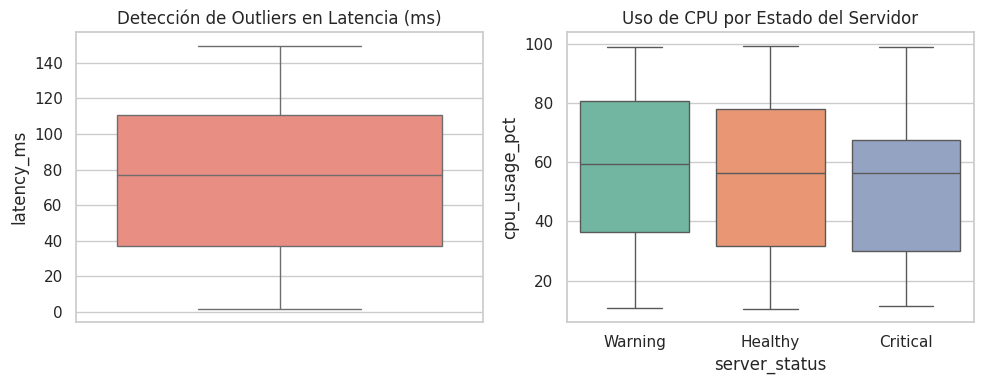

In [8]:
# ANÁLISIS ESTADÍSTICO (MÓDULO 2)

# 1. Medidas de tendencia central y dispersión
resumen = df_clean[
    ["cpu_usage_pct", "ram_usage_pct", "disk_io_mbps", "latency_ms"]
].describe()
resumen.loc["mediana"] = df_clean[
    ["cpu_usage_pct", "ram_usage_pct", "disk_io_mbps", "latency_ms"]
].median()

print("=== RESUMEN ESTADÍSTICO ===")
print(resumen.round(2))

# 2. Visualización de Outliers y Relaciones
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean["latency_ms"], color="salmon")
plt.title("Detección de Outliers en Latencia (ms)")

plt.subplot(1, 2, 2)
sns.boxplot(
    data=df_clean, x="server_status", y="cpu_usage_pct", palette="Set2"
)
plt.title("Uso de CPU por Estado del Servidor")

plt.tight_layout()
plt.show()

=== REPORTE DE CLASIFICACIÓN CORREGIDO ===
              precision    recall  f1-score   support

           0       0.92      0.78      0.85        78
           1       0.50      0.77      0.61        22

    accuracy                           0.78       100
   macro avg       0.71      0.78      0.73       100
weighted avg       0.83      0.78      0.79       100



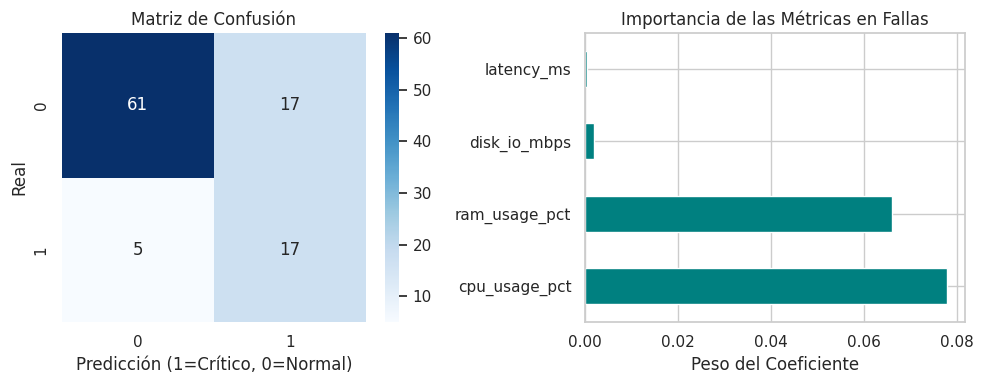

In [9]:
# MODELO PREDICTIVO Y EVALUACIÓN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Definimos una condición lógica realista para servidores críticos
# Un servidor es crítico si el uso de CPU > 80% o la RAM > 85%
df_clean['is_critical'] = ((df_clean['cpu_usage_pct'] > 80) | (df_clean['ram_usage_pct'] > 85)).astype(int)

X = df_clean[['cpu_usage_pct', 'ram_usage_pct', 'disk_io_mbps', 'latency_ms']]
y = df_clean['is_critical']

# División del conjunto de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenamiento del modelo
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 3. Evaluación
print("=== REPORTE DE CLASIFICACIÓN CORREGIDO ===")
print(classification_report(y_test, y_pred))

# 4. Gráficos finales
plt.figure(figsize=(10, 4))

# Matriz de Confusión
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción (1=Crítico, 0=Normal)")
plt.ylabel("Real")

# Coeficientes del modelo
plt.subplot(1, 2, 2)
coefs = pd.Series(model.coef_[0], index=X.columns)
coefs.plot(kind="barh", color="teal")
plt.title("Importancia de las Métricas en Fallas")
plt.xlabel("Peso del Coeficiente")

plt.tight_layout()
plt.show()